<a href="https://colab.research.google.com/github/kwerulik/Computer-Vision-Waste-Classification/blob/main/ML_Projekt_MLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("hassnainzaidi/garbage-classification")

# print("Path to dataset files:", path)

import kagglehub

# Download latest version
path = kagglehub.dataset_download("asdasdasasdas/garbage-classification")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'garbage-classification' dataset.
Path to dataset files: /kaggle/input/garbage-classification


In [4]:
import os
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import image_dataset_from_directory
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [5]:
np.random.seed(42)
tf.random.set_seed(42)

data_dir = os.path.join(path, "Garbage classification/Garbage classification")

In [6]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

BATCH_SIZE = 32
IMG_SIZE = (256, 256)

In [7]:
def set_datasets(img_size, batch_size):
    train_dataset = tf.keras.utils.image_dataset_from_directory(
        data_dir,
        validation_split=0.2,
        subset="training",
        seed=42,
        batch_size=batch_size,
        image_size=img_size,
        pad_to_aspect_ratio=True,
    )

    class_names = train_dataset.class_names

    val_test_pool = tf.keras.utils.image_dataset_from_directory(
        data_dir,
        validation_split=0.2,
        subset="validation",
        seed=42,
        batch_size=batch_size,
        image_size=img_size,
        pad_to_aspect_ratio=True,
    )

    pool_batches = tf.data.experimental.cardinality(val_test_pool)
    val_batches = pool_batches // 2

    val_dataset = val_test_pool.take(val_batches)
    test_dataset = val_test_pool.skip(val_batches)

    return train_dataset, val_dataset, test_dataset, class_names

In [8]:
def plot_history(history, title, file_prefix):
    os.makedirs("results/plots/accuracy", exist_ok=True)
    os.makedirs("results/plots/loss", exist_ok=True)

    plt.plot(history.history["accuracy"], label="train accuracy")
    plt.plot(history.history["val_accuracy"], label="validation accuracy")
    plt.xlabel("Epoka")
    plt.ylabel("Accuracy")
    plt.title(title + " - accuracy")
    plt.legend()
    acc_path = f"results/plots/accuracy/{file_prefix}_accuracy.png"
    plt.savefig(acc_path)
    plt.show()
    plt.close('all')

    plt.plot(history.history["loss"], label="train loss")
    plt.plot(history.history["val_loss"], label="validation loss")
    plt.xlabel("Epoka")
    plt.ylabel("Loss")
    plt.title(title + " - loss")
    plt.legend()
    loss_path = f"results/plots/loss/{file_prefix}_loss.png"
    plt.savefig(loss_path)
    plt.show()
    plt.close('all')

In [18]:
IMG_SIZE = (64, 64)
# IMG_SIZE = (256, 256)

BATCH_SIZE = 32
EPOCHS = 30
NUM_CLASSES = 6

train_dataset, val_dataset, test_dataset, class_names = set_datasets(IMG_SIZE, BATCH_SIZE)

Found 2527 files belonging to 6 classes.
Using 2022 files for training.
Found 2527 files belonging to 6 classes.
Using 505 files for validation.


In [ ]:
mlp_configs = [
    {
        "name": "Small MLP",
        "layer_count": 1,
        "neuron_count": "128",
        "build_fn": lambda: models.Sequential([
            layers.Rescaling(1./255, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
            layers.Flatten(),
            layers.Dense(128, activation="relu"),
            layers.Dense(NUM_CLASSES, activation="softmax")
        ])
    },
    {
        "name": "Wide MLP",
        "layer_count": 1,
        "neuron_count": "512",
        "build_fn": lambda: models.Sequential([
            layers.Rescaling(1./255, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
            layers.Flatten(),
            layers.Dense(512, activation="relu"),
            layers.Dense(NUM_CLASSES, activation="softmax")
        ])
    },
    {
        "name": "Deep MLP",
        "layer_count": 3,
        "neuron_count": "256->128->64",
        "build_fn": lambda: models.Sequential([
            layers.Rescaling(1./255, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
            layers.Flatten(),
            layers.Dense(256, activation="relu"),
            layers.Dense(128, activation="relu"),
            layers.Dense(64, activation="relu"),
            layers.Dense(NUM_CLASSES, activation="softmax")
        ])
    },
    {
        "name": "Dropout MLP",
        "layer_count": 2,
        "neuron_count": "256->128 (Drop)",
        "build_fn": lambda: models.Sequential([
            layers.Rescaling(1./255, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
            layers.Flatten(),
            layers.Dense(256, activation="relu"),
            layers.Dropout(0.3),
            layers.Dense(128, activation="relu"),
            layers.Dropout(0.3),
            layers.Dense(NUM_CLASSES, activation="softmax")
        ])
    }
]


Uruchamiam: Small MLP


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,572,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,573,766 (6.00 MB)

 Trainable params: 1,573,766 (6.00 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - accuracy: 0.2463 - loss: 3.6208 - val_accuracy: 0.2500 - val_loss: 2.4917
Epoch 2/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.3294 - loss: 1.7784 - val_accuracy: 0.2891 - val_loss: 1.6225
Epoch 3/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.3783 - loss: 1.6429 - val_accuracy: 0.2969 - val_loss: 2.1497
Epoch 4/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.3976 - loss: 1.5821 - val_accuracy: 0.3281 - val_loss: 1.7160
Epoch 5/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.4090 - loss: 1.5274 - val_accuracy: 0.3945 - val_loss: 1.6021
Epoch 6/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.3858 - loss: 1.6650 - val_accuracy: 0.3438 - val_loss: 1.6504
Epoch 7/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.4382 - loss: 1.4406 - val_accuracy: 0.3125 - val_loss: 1.9155
Epoch 8/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.4466 - loss: 1.4604 - val_accuracy: 0.2930 - v

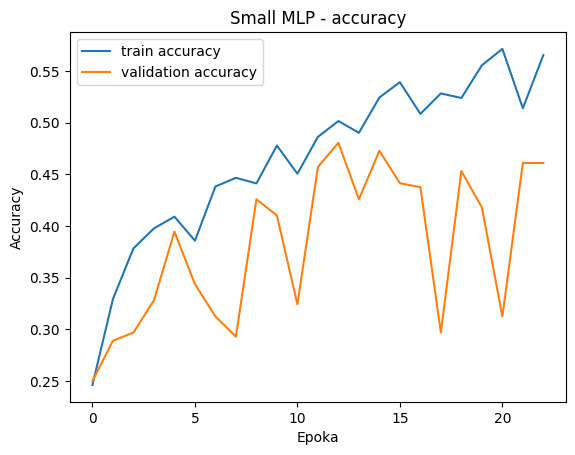

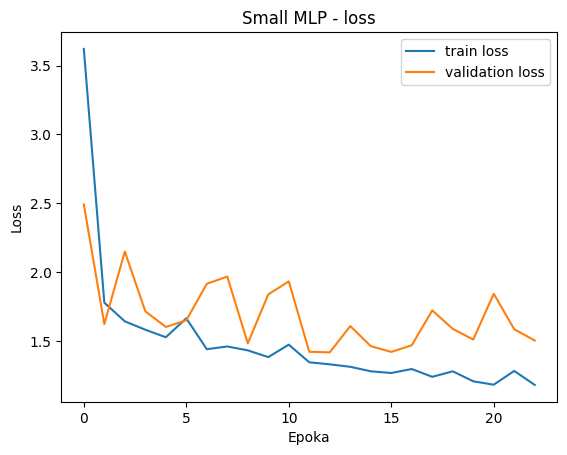


Uruchamiam: Wide MLP


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     6,291,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │         3,078 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,295,046 (24.01 MB)

 Trainable params: 6,295,046 (24.01 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 7s 93ms/step - accuracy: 0.2557 - loss: 5.2853 - val_accuracy: 0.2266 - val_loss: 1.8669
Epoch 2/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 97ms/step - accuracy: 0.3432 - loss: 1.7469 - val_accuracy: 0.2266 - val_loss: 2.2614
Epoch 3/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 102ms/step - accuracy: 0.3660 - loss: 1.7950 - val_accuracy: 0.2188 - val_loss: 2.5862
Epoch 4/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 91ms/step - accuracy: 0.4080 - loss: 1.6096 - val_accuracy: 0.3320 - val_loss: 1.8113
Epoch 5/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 7s 101ms/step - accuracy: 0.4233 - loss: 1.5199 - val_accuracy: 0.3359 - val_loss: 1.9173
Epoch 6/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 104ms/step - accuracy: 0.4441 - loss: 1.5364 - val_accuracy: 0.4180 - val_loss: 1.5400
Epoch 7/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 93ms/step - accuracy: 0.4629 - loss: 1.4179 - val_accuracy: 0.3516 - val_loss: 1.7580
Epoch 8/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 91ms/step - accuracy: 0.4693 - loss: 1.4563 - val_accuracy: 0.33

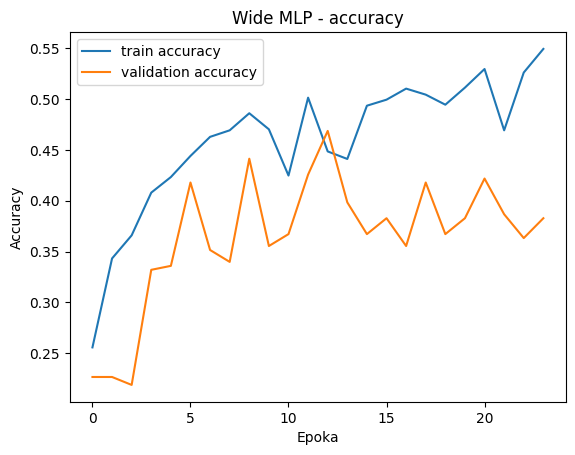

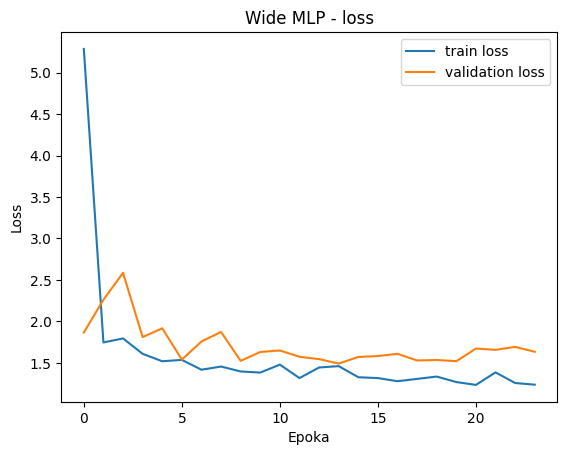


Uruchamiam: Deep MLP


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     3,145,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,187,526 (12.16 MB)

 Trainable params: 3,187,526 (12.16 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - accuracy: 0.2532 - loss: 2.1714 - val_accuracy: 0.4180 - val_loss: 1.6338
Epoch 2/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.3412 - loss: 1.6958 - val_accuracy: 0.3320 - val_loss: 1.7026
Epoch 3/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 59ms/step - accuracy: 0.3595 - loss: 1.6054 - val_accuracy: 0.2891 - val_loss: 1.6391
Epoch 4/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - accuracy: 0.4075 - loss: 1.4935 - val_accuracy: 0.3672 - val_loss: 1.5672
Epoch 5/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.4273 - loss: 1.4653 - val_accuracy: 0.3867 - val_loss: 1.4882
Epoch 6/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - accuracy: 0.4530 - loss: 1.3810 - val_accuracy: 0.4219 - val_loss: 1.4750
Epoch 7/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 0.4862 - loss: 1.3376 - val_accuracy: 0.3477 - val_loss: 1.4970
Epoch 8/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.4758 - loss: 1.3454 - val_accuracy: 0.4062 - v

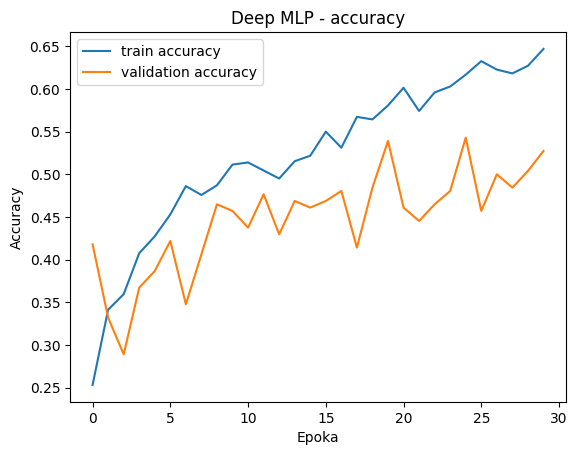

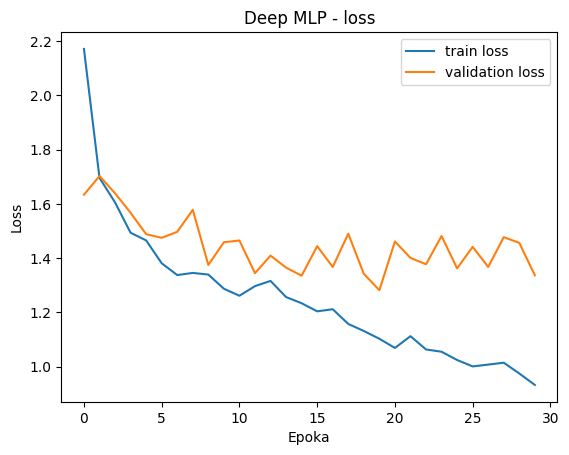


Uruchamiam: Dropout MLP


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_3 (Rescaling)         │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │     3,145,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,179,654 (12.13 MB)

 Trainable params: 3,179,654 (12.13 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - accuracy: 0.1978 - loss: 2.6911 - val_accuracy: 0.2109 - val_loss: 1.8555
Epoch 2/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 0.2221 - loss: 1.7403 - val_accuracy: 0.2344 - val_loss: 1.7130
Epoch 3/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - accuracy: 0.2344 - loss: 1.7324 - val_accuracy: 0.2383 - val_loss: 1.7578
Epoch 4/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.2339 - loss: 1.7434 - val_accuracy: 0.2500 - val_loss: 1.7394
Epoch 5/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.2364 - loss: 1.7308 - val_accuracy: 0.2461 - val_loss: 1.7518
Epoch 6/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.2324 - loss: 1.7252 - val_accuracy: 0.2734 - val_loss: 1.7242
Epoch 7/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.2319 - loss: 1.7232 - val_accuracy: 0.2461 - val_loss: 1.7415
Epoch 8/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - accuracy: 0.2329 - loss: 1.7230 - val_accuracy: 0.2578 - v

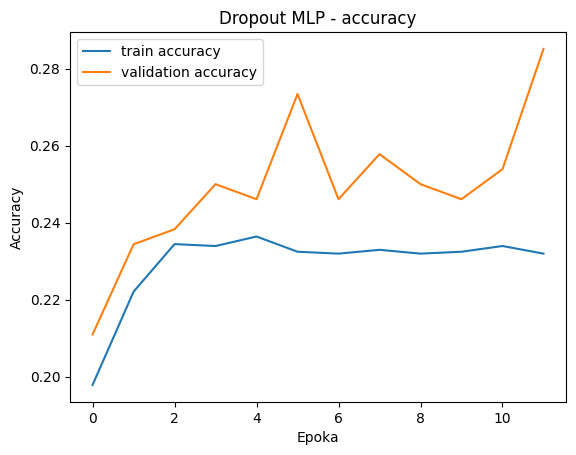

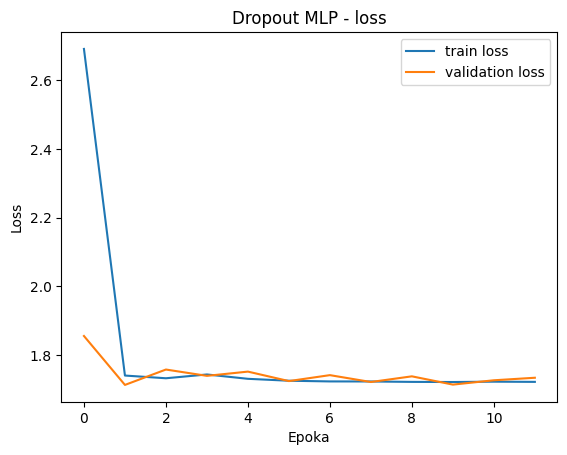

In [ ]:
csv_labels = ["model", "layer count", "img size", "filter count", "neuron count", "params", "final epoch", "train_acc", "train_loss", "val_acc", "val_loss", "test_acc", "test_loss"]
os.makedirs("results", exist_ok=True)

for config in mlp_configs:
    print(f"\nUruchamiam: {config['name']}")

    model = config["build_fn"]()
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    model.summary()

    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )

    history = model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=EPOCHS,
        callbacks=[early_stopping],
    )

    file_prefix = f"mlp_{config['name'].replace(' ', '_').lower()}_{IMG_SIZE[0]}x{IMG_SIZE[1]}"
    plot_history(history, config['name'], file_prefix)

    test_results = model.evaluate(test_dataset, verbose=0)

    val_loss_history = history.history["val_loss"]
    best_epoch_idx = val_loss_history.index(min(val_loss_history))

    param_count = model.count_params()
    final_epoch = best_epoch_idx + 1
    last_train_acc = history.history["accuracy"][best_epoch_idx]
    last_train_loss = history.history["loss"][best_epoch_idx]
    last_val_acc = history.history["val_accuracy"][best_epoch_idx]
    last_val_loss = history.history["val_loss"][best_epoch_idx]
    test_loss = test_results[0]
    test_acc = test_results[1]

    csv_data = [
        f"MLP ({config['name']})",
        config["layer_count"],
        f"{IMG_SIZE[0]}x{IMG_SIZE[1]}",
        "-",
        config["neuron_count"],
        param_count,
        final_epoch,
        last_train_acc,
        last_train_loss,
        last_val_acc,
        last_val_loss,
        test_acc,
        test_loss
    ]

    df = pd.DataFrame([csv_data], columns=csv_labels)
    csv_filename = "results/results.csv"

    if os.path.exists(csv_filename):
        df.to_csv(csv_filename, mode='a', header=False, index=False)
    else:
        df.to_csv(csv_filename, index=False)

    print("="*64)

In [ ]:
!zip -r /content/results_mlp.zip /content/results
from google.colab import files
files.download("/content/results_mlp.zip")

  adding: content/results/ (stored 0%)
  adding: content/results/results.csv (deflated 43%)
  adding: content/results/plots/ (stored 0%)
  adding: content/results/plots/accuracy/ (stored 0%)
  adding: content/results/plots/accuracy/mlp_deep_mlp_64x64_accuracy.png (deflated 5%)
  adding: content/results/plots/accuracy/mlp_small_mlp_64x64_accuracy.png (deflated 4%)
  adding: content/results/plots/accuracy/mlp_wide_mlp_64x64_accuracy.png (deflated 5%)
  adding: content/results/plots/accuracy/mlp_dropout_mlp_64x64_accuracy.png (deflated 8%)
  adding: content/results/plots/loss/ (stored 0%)
  adding: content/results/plots/loss/mlp_small_mlp_64x64_loss.png (deflated 7%)
  adding: content/results/plots/loss/mlp_dropout_mlp_64x64_loss.png (deflated 10%)
  adding: content/results/plots/loss/mlp_deep_mlp_64x64_loss.png (deflated 7%)
  adding: content/results/plots/loss/mlp_wide_mlp_64x64_loss.png (deflated 9%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

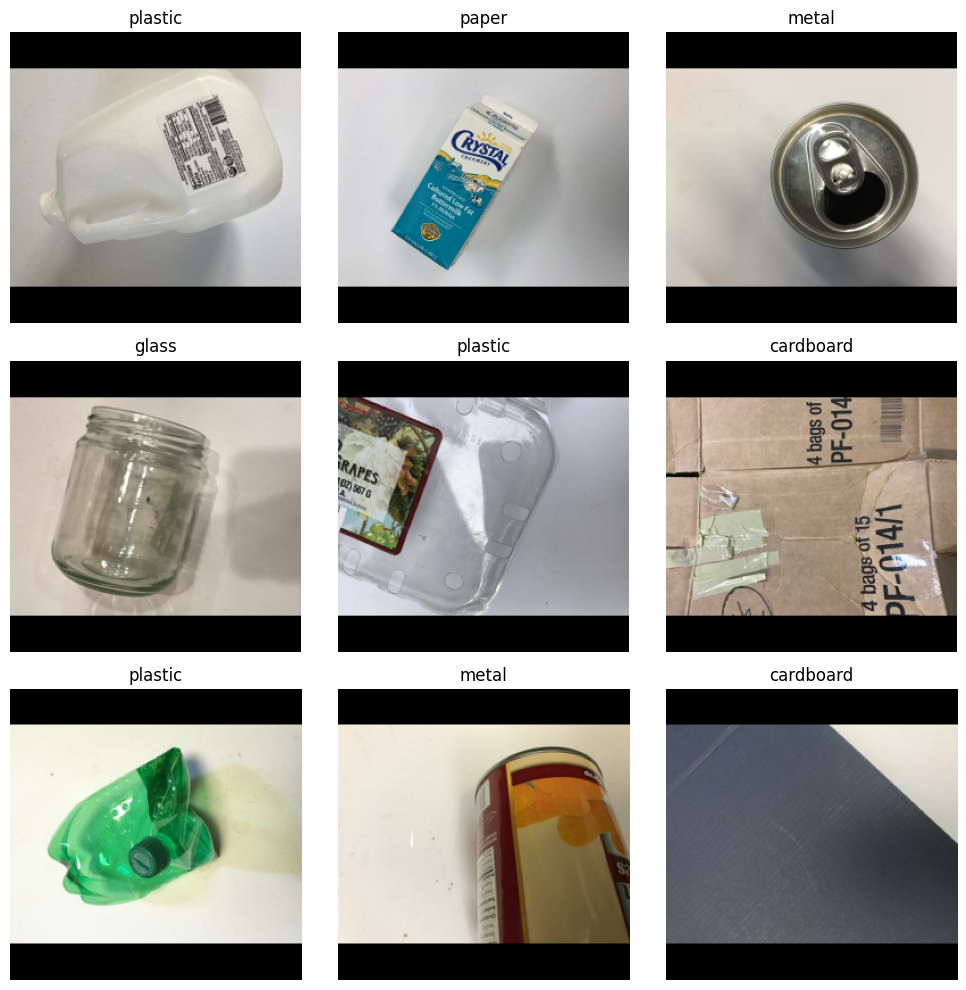

In [21]:
def plot_sample_images(dataset, class_names):
    plt.figure(figsize=(10, 10))
    for images, labels in dataset.take(1):
        for i in range(9):
            ax = plt.subplot(3, 3, i + 1)
            plt.imshow(images[i].numpy().astype("uint8"))
            plt.title(class_names[labels[i]])
            plt.axis("off")
    plt.tight_layout()
    plt.show()

plot_sample_images(train_dataset, class_names)